## Clone the file from Gihub

## Environment Setting

In [1]:
print("hi")

hi


In [3]:
# !git clone https://github.com/ericsujw/InstColorization.git

# #!sh scripts/download_model.sh
# # error legacy code - manual download
# # from google.colab import drive
# # drive.mount('/content/drive')
import gdown

# # File 1
# url1 = "https://drive.google.com/uc?id=1KoJTi_sUliv4unX0oKU4LrmqW848lg0c"
# gdown.download(url1, quiet=False)

# File 2
# url2 = "https://drive.google.com/uc?id=1dXda8H1WcxwHvlLZNicjwiRchMUTUXwA"
# gdown.download(url2, quiet=False)

# print("Download complete!")


# !cp checkpoints.zip ./InstColorization/checkpoints.zip
# !cp ViCoWDataset.zip ./InstColorization/ViCoWDataset.zip

In [4]:
# #!sh scripts/download_model.sh
# # error legacy code - manual download
# import zipfile

# with zipfile.ZipFile('checkpoints.zip', 'r') as zf:
#     zf.extractall()

# with zipfile.ZipFile('ViCoWDataset.zip', 'r') as zf:
#     zf.extractall()

In [5]:
# Updated PyTorch, torchvision, and detectron2 versions for compatibility with current Colab environments.
# Original versions torch==1.5 and detectron2==0.1.2 are too old and cause installation errors.
# PyYAML and dominate version constraints removed to resolve installation issues.
!pip install -U torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -U torch cython pyyaml visdom dominate gdown wheel setuptools cython numpy scikit-image
# !pip install -U cython pyyaml visdom
# !pip install -U dominate



Looking in indexes: https://download.pytorch.org/whl/cu121


In [6]:
# sudo apt update
# sudo apt install -y build-essential python3-dev python3-pip git cython3
!pip install -U 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'
# Use python -m pip install for detectron2 as it can be more robust for git installs.
!python -m pip install 'detectron2@git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/cocodataset/cocoapi.git to /tmp/pip-req-build-_9829hkc
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/cocoapi.git /tmp/pip-req-build-_9829hkc
  Resolved https://github.com/cocodataset/cocoapi.git to commit 8c9bcc3cf640524c4c20a9c40e89cb6a2f2fa0e9
  Preparing metadata (setup.py) ... done
  Created wheel for pycocotools: filename=pycocotools-2.0-cp312-cp312-linux_x86_64.whl size=424530 sha256=11b236fe78710e33393cd8bcd7d5fd6dca751cc1a5a5d0c5882f64c75465f68b
  Stored in directory: /tmp/pip-ephem-wheel-cache-cmxbfvg9/wheels/95/e6/c7/8ceda667bca7218619fea052622a0b11a37fb51c28c993fae3
Successfully built pycocotools
  Attempting uninstall: pycocotools
    Found existing installation: pycocotools 2.0.11
    Uninstalling pycocotools-2.0.11:
      Successfully uninstalled pycocotools-2.0.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of th

## Start Colorization

In [ ]:
cd InstColorization/

/home/h/InstColorization


## Download the Model

### Detect Object bounding box


Setting the Detectron2.

In [62]:
# Install detectron2 from source as pre-built wheels are not available for the current PyTorch/CUDA versions.
#!pip install 'git+https://github.com/facebookresearch/detectron2.git'

from os.path import join, isfile, isdir
from os import listdir
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from argparse import ArgumentParser

import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

import numpy as np
import cv2

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg

import torch

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_X_101_32x8d_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_X_101_32x8d_FPN_3x.yaml")
predictor = DefaultPredictor(cfg)

[12/16 21:35:26 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_X_101_32x8d_FPN_3x/139653917/model_final_2d9806.pkl ...


Let's create a bounding box folder to save our prediction results.

In [63]:
input_dir = "example"
image_list = [f for f in listdir(input_dir) if isfile(join(input_dir, f))]
output_npz_dir = "{0}_bbox".format(input_dir)
if os.path.isdir(output_npz_dir) is False:
    print('Create path: {0}'.format(output_npz_dir))
    os.makedirs(output_npz_dir)

Here we simply take L channel as our input and make sure that we can get consistent box prediction results even though the original image is color images.

In [64]:
for image_path in image_list:
    img = cv2.imread(join(input_dir, image_path))
    lab_image = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab_image)
    l_stack = np.stack([l_channel, l_channel, l_channel], axis=2)
    outputs = predictor(l_stack)
    save_path = join(output_npz_dir, image_path.split('.')[0])
    pred_bbox = outputs["instances"].pred_boxes.to(torch.device('cpu')).tensor.numpy()
    pred_scores = outputs["instances"].scores.cpu().data.numpy()
    np.savez(save_path, bbox = pred_bbox, scores = pred_scores)

Now we have all the images' prediction results.

In [65]:
!ls example_bbox

8b01a894fb91025a1dc77611838e9d13.npz  frame_0027.npz  frame_0078.npz
925f179ba736e15e89bfd6d88e0bba56.npz  frame_0053.npz


### Colorize Images

We first set up some libraries and options

In [12]:
import sys
import time
from options.train_options import TestOptions
from models import create_model

import torch
from tqdm import tqdm_notebook

from fusion_dataset import Fusion_Testing_Dataset
from util import util
import multiprocessing
multiprocessing.set_start_method('spawn', True)

torch.backends.cudnn.benchmark = True

sys.argv = [sys.argv[0]]
opt = TestOptions().parse()

Then we need to create a results folder to save our predicted color images and read the dataset loader.

In [13]:
save_img_path = opt.results_img_dir
if os.path.isdir(save_img_path) is False:
    print('Create path: {0}'.format(save_img_path))
    os.makedirs(save_img_path)
opt.batch_size = 1
dataset = Fusion_Testing_Dataset(opt, -1)
dataset_loader = torch.utils.data.DataLoader(dataset, batch_size=opt.batch_size)

dataset_size = len(dataset)
print('#Testing images = %d' % dataset_size)

#Testing images = 4


Load the pre-trained model.

In [14]:
model = create_model(opt)
model.setup_to_test('coco_finetuned_mask_256_ffs')

initialize network with normal
initialize network with normal
initialize network with normal
model [FusionModel] was created
load Fusion model from checkpoints/coco_finetuned_mask_256_ffs/latest_net_GF.pth


In [15]:
ls

 InstColorization.ipynb
 LICENSE
 README.md
 README_TRAIN.md
'ViCoW A Dataset for Colorization and Restoration of Vietnam War Imagery'/
 ViCoWDataset.zip
 __pycache__/
 check.py
 checkpoints/
 checkpoints.zip
 data/
 download.py
 env.yml
 example/
 example_bbox/
 fusion_dataset.py
 image_util.py
 imgs/
 inference_bbox.py
 models/
 options/
 results/
 scripts/
 test_fusion.py
 train.py
 train_data/
 util/


Start to colorize every images in `dataset_loader`.

In [16]:
!pip install ipywidgets jupyterlab jupyterlab_widgets

In [17]:
count_empty = 0
for data_raw in tqdm_notebook(dataset_loader):
    data_raw['full_img'][0] = data_raw['full_img'][0].cuda()
    if data_raw['empty_box'][0] == 0:
        data_raw['cropped_img'][0] = data_raw['cropped_img'][0].cuda()
        box_info = data_raw['box_info'][0]
        box_info_2x = data_raw['box_info_2x'][0]
        box_info_4x = data_raw['box_info_4x'][0]
        box_info_8x = data_raw['box_info_8x'][0]
        cropped_data = util.get_colorization_data(data_raw['cropped_img'], opt, ab_thresh=0, p=opt.sample_p)
        full_img_data = util.get_colorization_data(data_raw['full_img'], opt, ab_thresh=0, p=opt.sample_p)
        model.set_input(cropped_data)
        model.set_fusion_input(full_img_data, [box_info, box_info_2x, box_info_4x, box_info_8x])
        model.forward()
    else:
        count_empty += 1
        full_img_data = util.get_colorization_data(data_raw['full_img'], opt, ab_thresh=0, p=opt.sample_p)
        model.set_forward_without_box(full_img_data)
    model.save_current_imgs(join(save_img_path, data_raw['file_id'][0] + '.png'))
print('{0} images without bounding boxes'.format(count_empty))

/tmp/ipykernel_31753/2081716843.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for data_raw in tqdm_notebook(dataset_loader):


  0%|          | 0/4 [00:00<?, ?it/s]

0 images without bounding boxes


In [18]:
# from google.colab.patches import cv2_imshow

# img_name_list = ['000000022969', '000000023781', '000000046872', '000000050145', '574100c6e31a1dcd096476eb2d632b3c', 'frame_0251']
# show_index = 2

# img = cv2.imread('example/'+img_name_list[show_index]+'.jpg')
# lab_image = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
# l_channel, _, _ = cv2.split(lab_image)

# img = cv2.imread('results/'+img_name_list[show_index]+'.png')
# lab_image = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
# _, a_pred, b_pred = cv2.split(lab_image)
# a_pred = cv2.resize(a_pred, (l_channel.shape[1], l_channel.shape[0]))
# b_pred = cv2.resize(b_pred, (l_channel.shape[1], l_channel.shape[0]))
# gray_color = np.ones_like(a_pred) * 128

# gray_image = cv2.cvtColor(np.stack([l_channel, gray_color, gray_color], 2), cv2.COLOR_LAB2BGR)
# color_image = cv2.cvtColor(np.stack([l_channel, a_pred, b_pred], 2), cv2.COLOR_LAB2BGR)

# # save_img_path = 'results_origin/'
# # if os.path.isdir(save_img_path) is False:
# #     print('Create path: {0}'.format(save_img_path))
# #     os.makedirs(save_img_path)

# # cv2.imwrite('results_origin/'+img_name_list[show_index]+'.png', color_image)

# cv2_imshow(np.concatenate([gray_image, color_image], 1))

Found images: ['925f179ba736e15e89bfd6d88e0bba56', 'frame_0027', '8b01a894fb91025a1dc77611838e9d13', 'frame_0053']
Processing: 925f179ba736e15e89bfd6d88e0bba56


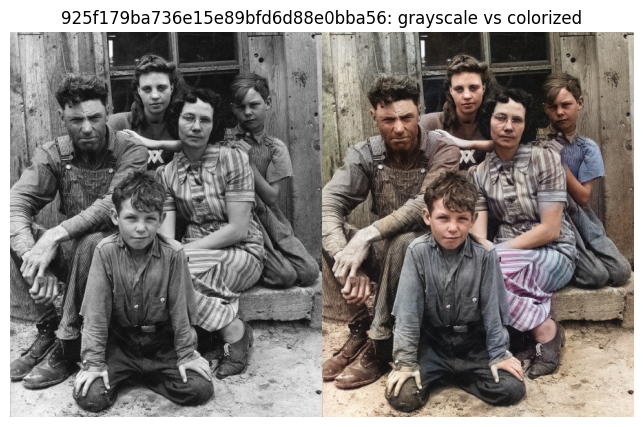

Processing: frame_0027


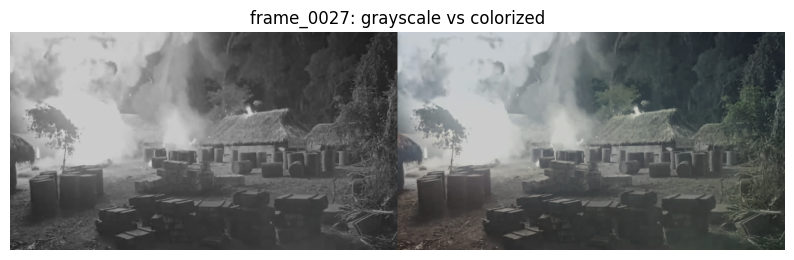

Processing: 8b01a894fb91025a1dc77611838e9d13


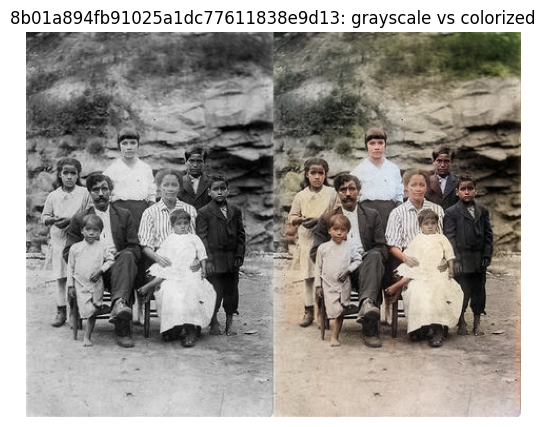

Processing: frame_0053


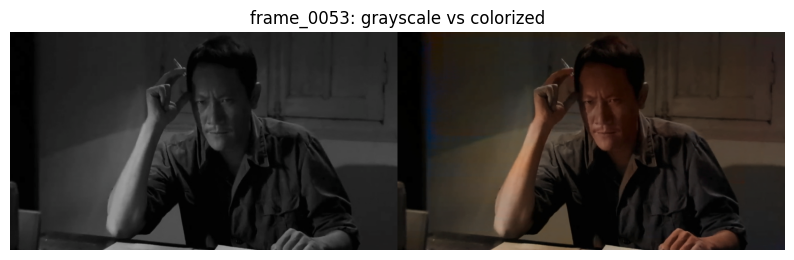

In [19]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

example_dir = "example/"
result_dir = "results/"

# Lấy danh sách tên file
img_name_list = [
    os.path.splitext(f)[0]
    for f in os.listdir(example_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

print("Found images:", img_name_list)

def show_img_bgr(img, title=""):
    """Hiển thị ảnh BGR trong Jupyter bằng matplotlib"""
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 5))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

for name in img_name_list:
    print("Processing:", name)

    # Load ảnh gốc
    img = cv2.imread(os.path.join(example_dir, name + '.jpg'))
    if img is None:
        print("Skip:", name, "- not found original image")
        continue

    lab_image = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, _, _ = cv2.split(lab_image)

    # Load ảnh kết quả
    img_pred = cv2.imread(os.path.join(result_dir, name + '.png'))
    if img_pred is None:
        print("Skip:", name, "- result image missing")
        continue

    lab_pred = cv2.cvtColor(img_pred, cv2.COLOR_BGR2LAB)
    _, a_pred, b_pred = cv2.split(lab_pred)

    # Resize A, B về size L
    a_pred = cv2.resize(a_pred, (l_channel.shape[1], l_channel.shape[0]))
    b_pred = cv2.resize(b_pred, (l_channel.shape[1], l_channel.shape[0]))

    # Tạo grayscale (L + a=128 + b=128)
    gray_color = np.ones_like(a_pred) * 128
    gray_image = cv2.cvtColor(np.stack([l_channel, gray_color, gray_color], 2), cv2.COLOR_LAB2BGR)

    # Tạo ảnh colorized
    color_image = cv2.cvtColor(np.stack([l_channel, a_pred, b_pred], 2), cv2.COLOR_LAB2BGR)

    # Ghép và show
    combined = np.concatenate([gray_image, color_image], 1)
    show_img_bgr(combined, f"{name}: grayscale vs colorized")



In [ ]:
# !sh scripts/prepare_cocostuff.sh

import os 
import shutil

src = r"InstColorization/ViCoW-test"
dst = r"train_data/train2017"

# Đảm bảo thư mục đích tồn tại
os.makedirs(dst, exist_ok=True)

# Lấy danh sách file
files = [f for f in os.listdir(src) if os.path.isfile(os.path.join(src, f))]
files.sort()  # nếu muốn copy theo thứ tự tên

# Giới hạn 10 file
files_to_copy = files[:10]

for filename in files:
    src_file = os.path.join(src, filename)
    dst_file = os.path.join(dst, filename)
    shutil.copy2(src_file, dst_file)

print(f"Copy xong {len(files)} file!")

Copy xong 700 file!


In [21]:
!sh scripts/prepare_train_box.sh

/home/h/312inst/lib/python3.12/site-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[12/16 18:32:51 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_X_101_32x8d_FPN_3x/139653917/model_final_2d9806.pkl ...
  0%|                                                   | 0/700 [00:00<?, ?it/s]ok
/home/h/312inst/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W1216 18:32:56.097000 3

In [22]:
# !sh scripts/train.sh

In [44]:
import subprocess
import sys

subprocess.Popen(
    [sys.executable, "-m", "visdom.server", "-p", "8098"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

<Popen: returncode: None args: ['/home/h/312inst/bin/python', '-m', 'visdom....>

In [40]:
# Stage 1: Training Full Image Colorization
!mkdir ./checkpoints/coco_full
!cp ./checkpoints/coco_finetuned_mask_256_ffs/latest_net_G.pth ./checkpoints/coco_full/
!python train.py --stage full --name coco_full --sample_p 1.0 --niter 30 --niter_decay 10 --load_model --lr 0.0005 --model train --fineSize 256 --batch_size 8 --display_ncols 3 --display_freq 1600 --print_freq 1600 --train_img_dir 'train_data/train2017'


mkdir: cannot create directory ‘./checkpoints/coco_full’: File exists
#training images = 653
initialize network with normal
model [TrainModel] was created
loading the model from ./checkpoints/coco_full/latest_net_G.pth
Setting up a new session...
create web directory ./checkpoints/coco_full/web...
batch:  43%|███████████████▎                    | 35/82 [00:10<00:12,  3.79it/s]/home/h/InstColorization/models/train_model.py:174: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.avg_losses[name] = float(getattr(self, 'loss_' + name)) + self.avg_loss_alpha * self.avg_losses[name]

epoch: 100%|████████████████████████████████████| 40/40 [16:42<00:00, 25.05s/it]


In [41]:
# Stage 2: Training Instance Image Colorization
!mkdir ./checkpoints/coco_instance
!cp ./checkpoints/coco_full/latest_net_G.pth ./checkpoints/coco_instance/
!python train.py --stage instance --name coco_instance --sample_p 1.0 --niter 30 --niter_decay 10 --load_model --lr 0.0005 --model train --fineSize 256 --batch_size 8 --display_ncols 3 --display_freq 1600 --print_freq 1600 --train_img_dir 'train_data/train2017'


mkdir: cannot create directory ‘./checkpoints/coco_instance’: File exists
#training images = 653
initialize network with normal
model [TrainModel] was created
loading the model from ./checkpoints/coco_instance/latest_net_G.pth
Setting up a new session...
create web directory ./checkpoints/coco_instance/web...
batch:  43%|███████████████▎                    | 35/82 [00:10<00:12,  3.79it/s]/home/h/InstColorization/models/train_model.py:174: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.avg_losses[name] = float(getattr(self, 'loss_' + name)) + self.avg_loss_alpha * self.avg_losses[name]

epoch: 100%|████████████████████████████████████| 40/40 [15:51<00:00, 23.78s/it]


In [53]:
# Stage 3: Training Fusion Module
!mkdir ./checkpoints/coco_mask
!cp ./checkpoints/coco_full/latest_net_G.pth ./checkpoints/coco_mask/latest_net_GF.pth
!cp ./checkpoints/coco_instance/latest_net_G.pth ./checkpoints/coco_mask/latest_net_G.pth
!cp ./checkpoints/coco_full/latest_net_G.pth ./checkpoints/coco_mask/latest_net_GComp.pth
!python train.py --stage fusion --name coco_mask --sample_p 1.0 --niter 10 --niter_decay 2 --lr 0.00005 --model train --load_model --display_ncols 4 --fineSize 128 --batch_size 1 --display_freq 500 --print_freq 500 --train_img_dir 'train_data/train2017'


mkdir: cannot create directory ‘./checkpoints/coco_mask’: File exists
#training images = 653
initialize network with normal
initialize network with normal
initialize network with normal
model [TrainModel] was created
loading the model from ./checkpoints/coco_mask/latest_net_G.pth
loading the model from ./checkpoints/coco_mask/latest_net_GF.pth
loading the model from ./checkpoints/coco_mask/latest_net_GComp.pth
Setting up a new session...
create web directory ./checkpoints/coco_mask/web...
batch:  76%|█████████████████████████▉        | 499/653 [02:51<00:39,  3.88it/s]/home/h/InstColorization/models/train_model.py:174: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.avg_losses[name] = float(getattr(self, 'loss_' + name)) + self.avg_loss_alpha * self.avg_losses[name]

epoch: 100%|██████████████

In [66]:
!python test_fusion.py --name test_fusion --sample_p 1.0 --model fusion --fineSize 256 --test_img_dir example --results_img_dir results

#Testing images = 5
initialize network with normal
initialize network with normal
initialize network with normal
model [FusionModel] was created
load Fusion model from checkpoints/coco_mask/latest_net_GF.pth
100%|█████████████████████████████████████████████| 5/5 [00:18<00:00,  3.79s/it]
0 images without bounding boxes


Found images: ['frame_0078', '925f179ba736e15e89bfd6d88e0bba56', 'frame_0027', '8b01a894fb91025a1dc77611838e9d13', 'frame_0053']
Processing: frame_0078


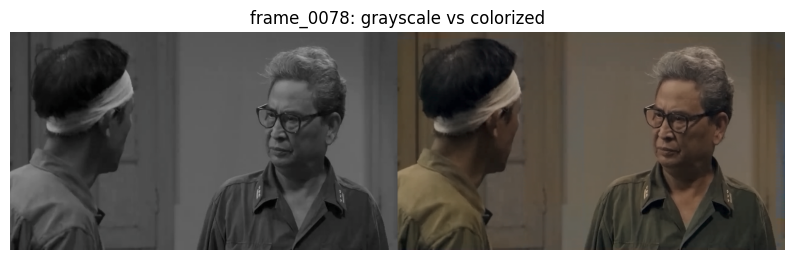

Processing: 925f179ba736e15e89bfd6d88e0bba56


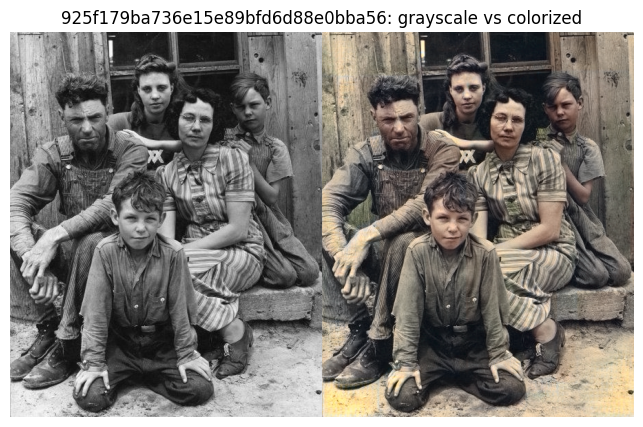

Processing: frame_0027


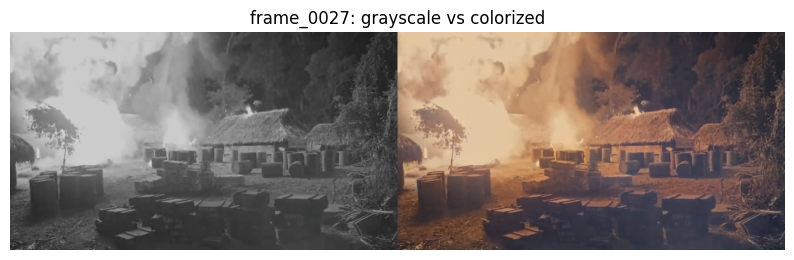

Processing: 8b01a894fb91025a1dc77611838e9d13


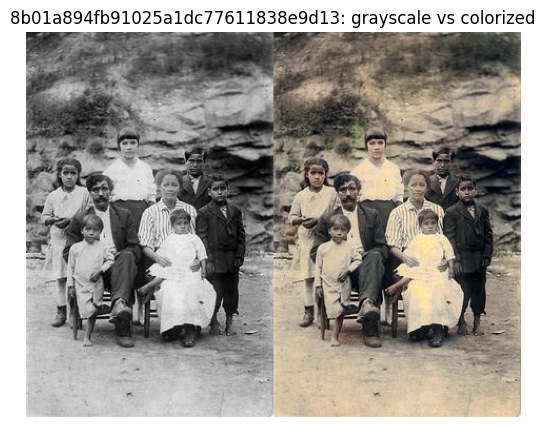

Processing: frame_0053


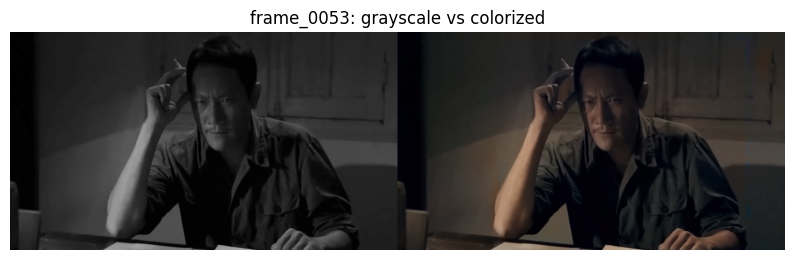

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

example_dir = "ViCoW-test/"
result_dir = "results/"

# Lấy danh sách tên file
img_name_list = [
    os.path.splitext(f)[0]
    for f in os.listdir(example_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

print("Found images:", img_name_list)

def show_img_bgr(img, title=""):
    """Hiển thị ảnh BGR trong Jupyter bằng matplotlib"""
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 5))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

for name in img_name_list:
    print("Processing:", name)

    # Load ảnh gốc
    img = cv2.imread(os.path.join(example_dir, name + '.jpg'))
    if img is None:
        print("Skip:", name, "- not found original image")
        continue

    lab_image = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, _, _ = cv2.split(lab_image)

    # Load ảnh kết quả
    img_pred = cv2.imread(os.path.join(result_dir, name + '.png'))
    if img_pred is None:
        print("Skip:", name, "- result image missing")
        continue

    lab_pred = cv2.cvtColor(img_pred, cv2.COLOR_BGR2LAB)
    _, a_pred, b_pred = cv2.split(lab_pred)

    # Resize A, B về size L
    a_pred = cv2.resize(a_pred, (l_channel.shape[1], l_channel.shape[0]))
    b_pred = cv2.resize(b_pred, (l_channel.shape[1], l_channel.shape[0]))

    # Tạo grayscale (L + a=128 + b=128)
    gray_color = np.ones_like(a_pred) * 128
    gray_image = cv2.cvtColor(np.stack([l_channel, gray_color, gray_color], 2), cv2.COLOR_LAB2BGR)

    # Tạo ảnh colorized
    color_image = cv2.cvtColor(np.stack([l_channel, a_pred, b_pred], 2), cv2.COLOR_LAB2BGR)

    # Ghép và show
    combined = np.concatenate([gray_image, color_image], 1)
    show_img_bgr(combined, f"{name}: grayscale vs colorized")